## Experiment 03

## 1. Experiment Settings
- Sample size (n): 5000
- X1 dimension (d): 10
- X2 dimension (p): 500
- X1 and X2 are independent.
- Linear relationship between predictor (X1 and X2) and response (Y).
- Data were generated randomly 5 times to get 5 results from each model for analyzation.
- Use loop to tune each model

In [1]:
import sys
sys.path.append("../src")

from generate_predictors import generate_predictors
from sklearn.model_selection import train_test_split

from models.lasso import tune_lasso
from models.lasso import fit_lasso

from models.ridge import tune_ridge
from models.ridge import fit_ridge

from models.random_forest import tune_random_forest
from models.random_forest import fit_random_forest

from models.neural_network import tune_neural_network
from models.neural_network import fit_neural_network

import numpy as np

## 2. Simulation

### Data Generation 1

In [2]:
np.random.seed(32)
# Configuration for predictors
X1_CONFIG = {
    "size": 5000,
    "dimension": 10,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 0,
        "std": 1
    }
}

X2_CONFIG = {
    "size": 5000,
    "dimension": 500,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 2,
        "std": 5
    }
}

# Generate X1
X1 = generate_predictors(X1_CONFIG)

# Generate X2
X2 = generate_predictors(X2_CONFIG)

 # Generate noise
noise = np.random.normal(
    0,
    1,
    X1.shape[0]
    )
    
# Generate Y
## Strong sparse signal from X1
beta_x1 = np.array([3, 2, 1])

y_x1 = X1[:, :3] @ beta_x1

## Weaker signal from 150 X2 variables
p = X2.shape[1]
n_active = 150

rng = np.random.default_rng(seed=32)

active_indices = rng.choice(
        p,
        size=n_active,
        replace=False
    )

beta_x2 = np.zeros(p)

beta_x2[active_indices] = rng.normal(
        0,
        0.3,
        n_active
    )

y_x2 = X2 @ beta_x2

Y = y_x1 + y_x2 + noise
    
# Combine the feature matrices
X = np.hstack((X1, X2))

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
    )

### Model Tuning

In [3]:
tuning_models = {
    "Lasso": (
        tune_lasso,
        {
            "alphas": [0.001, 0.01, 0.1, 1, 10]
        }
    ),
    "Ridge": (
        tune_ridge,
        {
            "alphas": [0.001, 0.01, 0.1, 1, 10, 100]
        }
    ),
    "Random Forest": (
        tune_random_forest,
        {
            "param_grid": {
            "n_estimators": [100],
            "max_depth": [10, 20, None],
            "min_samples_leaf": [1, 5],
            "max_features": [0.5, 1.0]
            }
        }
    ),
    "Neural Network": (
        tune_neural_network,
        {
            "param_grid": {
            "hidden_layer_sizes": [(50,),(100,),(100, 50)],
            "alpha": [0.0001, 0.001, 0.01],
            "learning_rate_init": [0.001, 0.01],
            "max_iter": [1000]
            }
        }
    )
}

best_params = {}

for model_name, (tune_function, tuning_params) in tuning_models.items():

    tuning_result = tune_function(
        X_train,
        Y_train,
        **tuning_params
    )

    if model_name in ["Lasso", "Ridge"]:
        best_params[model_name] = {
            "alpha": tuning_result["best_alpha"]
        }

    else:
        best_params[model_name] = {
            "params": tuning_result["best_params"]
        }

    print(model_name, best_params[model_name])

Lasso {'alpha': 0.01}
Ridge {'alpha': 1}
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Random Forest {'params': {'max_depth': 20, 'max_features': 1.0, 'min_samples_leaf': 5, 'n_estimators': 100}}
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Neural Network {'params': {'alpha': 0.01, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.01, 'max_iter': 1000}}


### Replicate 1

In [4]:
results = {
    "Lasso": [],
    "Ridge": [],
    "Random Forest": [],
    "Neural Network": []
}

models = {
    "Lasso": fit_lasso,
    "Ridge": fit_ridge,
    "Random Forest": fit_random_forest,
    "Neural Network": fit_neural_network
}

for model_name, fit_function in models.items():

    result = fit_function(
        X_train,
        Y_train,
        X_test,
        Y_test,
        **best_params[model_name]
    )

    results[model_name].append(result)

### Data generation 2

In [8]:
np.random.seed(23)
# Configuration for predictors
X1_CONFIG = {
    "size": 5000,
    "dimension": 10,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 0,
        "std": 1
    }
}

X2_CONFIG = {
    "size": 5000,
    "dimension": 500,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 2,
        "std": 5
    }
}

# Generate X1
X1 = generate_predictors(X1_CONFIG)

# Generate X2
X2 = generate_predictors(X2_CONFIG)

 # Generate noise
noise = np.random.normal(
    0,
    1,
    X1.shape[0]
    )
    
# Generate Y
## Strong sparse signal from X1
beta_x1 = np.array([3, 2, 1])

y_x1 = X1[:, :3] @ beta_x1

## Weaker signal from 150 X2 variables
p = X2.shape[1]
n_active = 150

rng = np.random.default_rng(seed=23)

active_indices = rng.choice(
        p,
        size=n_active,
        replace=False
    )

beta_x2 = np.zeros(p)

beta_x2[active_indices] = rng.normal(
        0,
        0.3,
        n_active
    )

y_x2 = X2 @ beta_x2

Y = y_x1 + y_x2 + noise
    
# Combine the feature matrices
X = np.hstack((X1, X2))

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
    )

### Replicate 2

In [9]:
for model_name, fit_function in models.items():

    result = fit_function(
        X_train,
        Y_train,
        X_test,
        Y_test,
        **best_params[model_name]
    )

    results[model_name].append(result)

### Data Generation 3

In [10]:
np.random.seed(56)
# Configuration for predictors
X1_CONFIG = {
    "size": 5000,
    "dimension": 10,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 0,
        "std": 1
    }
}

X2_CONFIG = {
    "size": 5000,
    "dimension": 500,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 2,
        "std": 5
    }
}

# Generate X1
X1 = generate_predictors(X1_CONFIG)

# Generate X2
X2 = generate_predictors(X2_CONFIG)

 # Generate noise
noise = np.random.normal(
    0,
    1,
    X1.shape[0]
    )
    
# Generate Y
## Strong sparse signal from X1
beta_x1 = np.array([3, 2, 1])

y_x1 = X1[:, :3] @ beta_x1

## Weaker signal from 150 X2 variables
p = X2.shape[1]
n_active = 150

rng = np.random.default_rng(seed=56)

active_indices = rng.choice(
        p,
        size=n_active,
        replace=False
    )

beta_x2 = np.zeros(p)

beta_x2[active_indices] = rng.normal(
        0,
        0.3,
        n_active
    )

y_x2 = X2 @ beta_x2

Y = y_x1 + y_x2 + noise
    
# Combine the feature matrices
X = np.hstack((X1, X2))

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
    )

### Replicate 3

In [11]:
for model_name, fit_function in models.items():

    result = fit_function(
        X_train,
        Y_train,
        X_test,
        Y_test,
        **best_params[model_name]
    )

    results[model_name].append(result)

### Data Generation 4

In [12]:
np.random.seed(44)

# Configuration for predictors
X1_CONFIG = {
    "size": 5000,
    "dimension": 10,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 0,
        "std": 1
    }
}

X2_CONFIG = {
    "size": 5000,
    "dimension": 500,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 2,
        "std": 5
    }
}

# Generate X1
X1 = generate_predictors(X1_CONFIG)

# Generate X2
X2 = generate_predictors(X2_CONFIG)

 # Generate noise
noise = np.random.normal(
    0,
    1,
    X1.shape[0]
    )
    
# Generate Y
## Strong sparse signal from X1
beta_x1 = np.array([3, 2, 1])

y_x1 = X1[:, :3] @ beta_x1

## Weaker signal from 150 X2 variables
p = X2.shape[1]
n_active = 150

rng = np.random.default_rng(seed=44)

active_indices = rng.choice(
        p,
        size=n_active,
        replace=False
    )

beta_x2 = np.zeros(p)

beta_x2[active_indices] = rng.normal(
        0,
        0.3,
        n_active
    )

y_x2 = X2 @ beta_x2

Y = y_x1 + y_x2 + noise
    
# Combine the feature matrices
X = np.hstack((X1, X2))

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
    )

### Replicate 4 

In [13]:
for model_name, fit_function in models.items():

    result = fit_function(
        X_train,
        Y_train,
        X_test,
        Y_test,
        **best_params[model_name]
    )

    results[model_name].append(result)

### Data Generation 5

In [14]:
np.random.seed(90)
# Configuration for predictors
X1_CONFIG = {
    "size": 5000,
    "dimension": 10,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 0,
        "std": 1
    }
}

X2_CONFIG = {
    "size": 5000,
    "dimension": 500,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 2,
        "std": 5
    }
}

# Generate X1
X1 = generate_predictors(X1_CONFIG)

# Generate X2
X2 = generate_predictors(X2_CONFIG)

 # Generate noise
noise = np.random.normal(
    0,
    1,
    X1.shape[0]
    )
    
# Generate Y
## Strong sparse signal from X1
beta_x1 = np.array([3, 2, 1])

y_x1 = X1[:, :3] @ beta_x1

## Weaker signal from 150 X2 variables
p = X2.shape[1]
n_active = 150

rng = np.random.default_rng(seed=90)

active_indices = rng.choice(
        p,
        size=n_active,
        replace=False
    )

beta_x2 = np.zeros(p)

beta_x2[active_indices] = rng.normal(
        0,
        0.3,
        n_active
    )

y_x2 = X2 @ beta_x2

Y = y_x1 + y_x2 + noise
    
# Combine the feature matrices
X = np.hstack((X1, X2))

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
    )

### Replicate 5

In [15]:
for model_name, fit_function in models.items():

    result = fit_function(
        X_train,
        Y_train,
        X_test,
        Y_test,
        **best_params[model_name]
    )

    results[model_name].append(result)

## 3. Evaluation

In [16]:
import pandas as pd
import matplotlib.pyplot as plt


def evaluate_mse(
    lasso_results,
    ridge_results,
    rf_results,
    nn_results
):
    results = {
        "Lasso": lasso_results,
        "Ridge": ridge_results,
        "Random Forest": rf_results,
        "Neural Network": nn_results
    }

    data = []

    for model_name, model_results in results.items():
        for repeat, result in enumerate(model_results, start=1):
            data.append({
                "model": model_name,
                "repeat": repeat,
                "mse": result["mse"]
            })

    df = pd.DataFrame(data)

    return df

In [ ]:
mse_df = evaluate_mse(
    results["Lasso"],
    results["Ridge"],
    results["Random Forest"],
    results["Neural Network"]
)

print(mse_df)

             model  repeat         mse
0            Lasso       1    1.046448
1            Lasso       2    1.098459
2            Lasso       3    1.142446
3            Lasso       4    1.091493
4            Lasso       5    1.158322
5            Ridge       1    1.102952
6            Ridge       2    1.124154
7            Ridge       3    1.209713
8            Ridge       4    1.170913
9            Ridge       5    1.219869
10   Random Forest       1  251.074467
11   Random Forest       2  281.238236
12   Random Forest       3  256.410707
13   Random Forest       4  271.630654
14   Random Forest       5  268.120936
15  Neural Network       1    4.391779
16  Neural Network       2    3.919211
17  Neural Network       3    4.075065
18  Neural Network       4    4.271507
19  Neural Network       5    7.774862


In [19]:
average_mse = (
    mse_df
    .groupby("model")["mse"]
    .mean()
    .sort_values()
)

print(average_mse)

model
Lasso               1.107433
Ridge               1.165520
Neural Network      4.886485
Random Forest     265.695000
Name: mse, dtype: float64


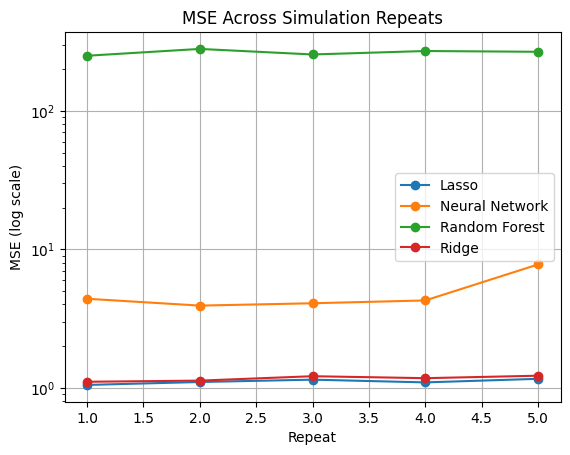

In [ ]:
for model_name, group in mse_df.groupby("model"):
    plt.plot(
        group["repeat"],
        group["mse"],
        marker="o",
        label=model_name
    )

plt.xlabel("Repeat")
plt.ylabel("MSE (log scale)")
plt.title("MSE Across Simulation Repeats")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.show()



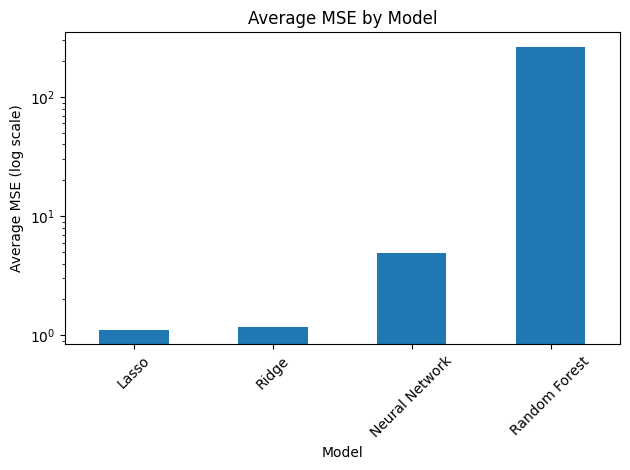

In [22]:
average_mse.plot(kind="bar")

plt.xlabel("Model")
plt.ylabel("Average MSE (log scale)")
plt.title("Average MSE by Model")
plt.yscale("log")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Conclusion 
Lasso achieved the lowest average MSE, closely followed by Ridge, while the Neural Network had a higher MSE and Random Forest performed substantially worse. The similar performance of Lasso and Ridge suggests that both methods are effective under a mixed linear signal with strong sparse effects and weaker distributed effects. Lasso's slightly lower MSE may indicate an advantage in capturing the stronger sparse signal, although further simulation replicates are needed to determine whether the difference is consistent.